# Update projections onto decoder axes: figures

The figures of `notebooks/20261002_prior_dependent_updates.ipynb`, drawn in the style of
`scripts/figure_generation/generate_updates_projections_plots_2.py`, and written out as png and svg.

The data are from `scripts/pseudo_decoding/belief_partitions/decoder_update_projections.py`. Each
bar is the mean, across (session, feature, split) units, of a unit's mean projection of
x[k+1] - x[k] onto its split's decoder axis. Error bars are SE across units. Stars are each bar's
`p_vs_0`, a two-sided sign-flip test against 0. The old script's stars were p-values against its
shuffle, and its dotted line was the shuffle mean. These runs have no shuffle, so there is no
dotted line.

- **Conditions**: chose X / correct, correct, incorrect, chose X / incorrect, one figure per axis.
- **Partitions**: the chose-X cells, one figure per axis and outcome. Pref has low / high X / high not X; conf has low / high, with high pooling High X and High Not X. Conf is also drawn with high split into high X / high not X, in figures suffixed `_split_high`; those cells need a run made after they were added to `md.compute_stats`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.update_projections_constants import CONDITION_TO_COLORS

plt.rcParams.update({"font.size": 15})

DATA_DIR = "/data/patrick_res/decoder_update_projections/both_StimOnset"
# the decoder_update_projections.py run to draw, its output prefix after "decoder_updates_"; must
# have p_vs_0, so a run made after it was added
RUN = "chunk_20_train_frac_0.3"
OUTPUT_DIR = f"/data/patrick_res/figures/wcst_paper/decoder_update_projections/{RUN}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Data

The contrast tests are printed here rather than drawn, as in the old figures.

In [2]:
def read(name):
    return pd.read_pickle(os.path.join(DATA_DIR, f"decoder_updates_{RUN}_{name}.pickle"))

stats = read("stats")
cells = read("cells")
conditions = read("conditions")
assert "p_vs_0" in cells.columns and "p_vs_0" in conditions.columns, f"run {RUN} predates p_vs_0; rerun it"

stats[["contrast", "axis", "plus", "minus", "mean_d", "n_units", "p"]].round(4)

,contrast,axis,plus,minus,mean_d,n_units,p
0,conf_cor,conf,cor/Low,cor/High,0.1725,2400,0.0001
1,conf_inc,conf,inc/Low,inc/High,0.2052,2400,0.0001
2,pref_cor,pref,cor/Low,cor/High X,0.0085,2248,0.0016
3,pref_inc,pref,inc/High Not X,inc/High X,0.0346,2091,0.0001


## Plotting

`format_updates` is the old script's. `plot_bars` draws precomputed means and SEs with
matplotlib, with error bars styled like seaborn's defaults, since only the summaries are saved.

In [3]:
MODE_YLABELS = {"pref": r"$\Delta \mathbf{r}$ along preference of X", "conf": r"$\Delta \mathbf{r}$ along confidence"}

def format_updates(fig, ax, ylabel):
    bottom, top = ax.get_ylim()
    max = np.max(np.abs([bottom, top]))

    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylim([-max, max])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    visualization_utils.format_plot(ax)
    fig.tight_layout()
    return fig, ax

def plot_bars(fig, ax, df, width):
    """
    df: one row per bar, in order, with color_key (a CONDITION_TO_COLORS key), mean, se, p_vs_0
    """
    x = np.arange(len(df))
    ax.bar(x, df["mean"], width=width, color=[CONDITION_TO_COLORS[k] for k in df.color_key])
    # seaborn's default error bars
    ax.errorbar(x, df["mean"], yerr=df["se"], fmt="none", ecolor=".26",
                elinewidth=plt.rcParams["lines.linewidth"] * 1.8)
    ax.set_xticks(x)
    # stars from the saved p_vs_0, above the bar's error bar, or above 0 for a negative bar, where the
    # paper figure had them moved by hand
    for xi, mean, se, p in zip(x, df["mean"], df["se"], df["p_vs_0"]):
        ax.annotate(visualization_utils.pval_to_stars(p), (xi, max(mean + se, 0)), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=12)

## Conditions

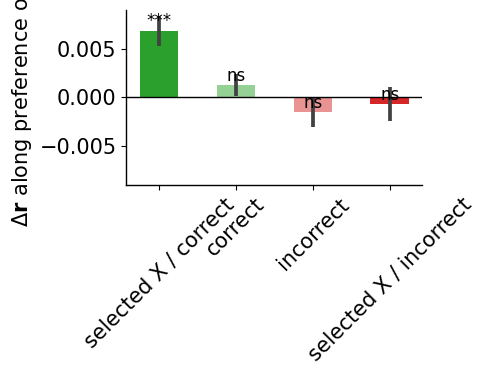

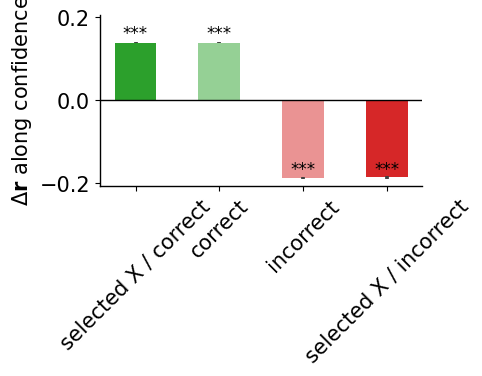

In [4]:
COND_ORDER = ["chose X / cor", "cor", "inc", "chose X / inc"]
COND_COLOR_KEYS = {"chose X / cor": "chose X / correct", "cor": "correct",
                   "inc": "incorrect", "chose X / inc": "chose X / incorrect"}
COND_TICK_LABELS = {"chose X / cor": "selected X / correct", "cor": "correct",
                    "inc": "incorrect", "chose X / inc": "selected X / incorrect"}

def plot_choice_reward(conditions, mode, ylabel, out_path):
    """
    out_path: the figure's path without extension; written as png and svg
    """
    df = conditions[conditions.axis == mode].set_index("condition")
    # the all-choice conditions are absent from pair-split runs
    order = [c for c in COND_ORDER if c in df.index]
    df = df.loc[order].assign(color_key=[COND_COLOR_KEYS[c] for c in order])

    fig, ax = plt.subplots(figsize=(5, 4))
    plot_bars(fig, ax, df, width=0.5)
    ax.set_xticklabels([COND_TICK_LABELS[c] for c in order])
    fig, ax = format_updates(fig, ax, ylabel)

    fig.savefig(f"{out_path}.png")
    fig.savefig(f"{out_path}.svg")

for mode in ["pref", "conf"]:
    plot_choice_reward(conditions, mode, MODE_YLABELS[mode], f"{OUTPUT_DIR}/{mode}_choice_reward_int")

## Chose-X cells by partition

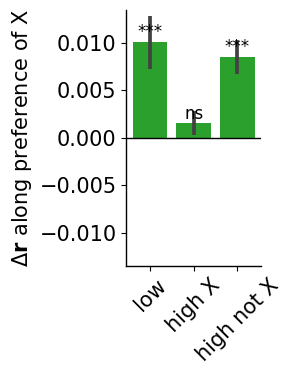

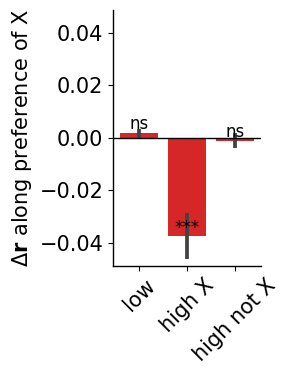

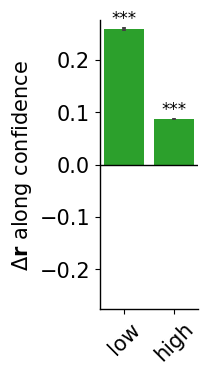

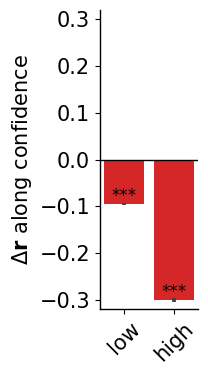

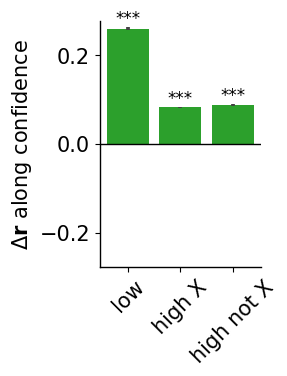

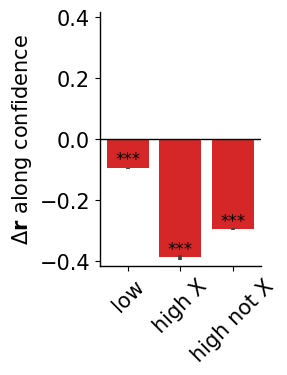

In [5]:
MODE_PARTITIONS = {"pref": ["Low", "High X", "High Not X"], "conf": ["Low", "High"]}
# conf with High split back into High X and High Not X, drawn as its own figure
CONF_SPLIT_HIGH_PARTITIONS = ["Low", "High X", "High Not X"]
OUTCOME_NAMES = {"cor": "correct", "inc": "incorrect"}
# CONDITION_TO_COLORS has no high key for conf; any partition of the outcome has the same color
PARTITION_COLOR_KEYS = {"Low": "low", "High X": "high X", "High Not X": "high not X", "High": "high X"}
PARTITION_TICK_LABELS = {"Low": "low", "High X": "high X", "High Not X": "high not X", "High": "high"}

def plot_chose_reward_by_partitions(cells, mode, outcome, ylabel, out_path, partitions=None):
    """
    out_path: the figure's path without extension; written as png and svg
    """
    partitions = MODE_PARTITIONS[mode] if partitions is None else partitions
    reward = OUTCOME_NAMES[outcome]
    df = cells[cells.axis == mode].set_index("cell").loc[[f"{outcome}/{p}" for p in partitions]]
    df = df.assign(color_key=[f"chose X / {reward} / {PARTITION_COLOR_KEYS[p]}" for p in partitions])

    fig, ax = plt.subplots(figsize=(1 + 2 / 3 * len(partitions), 4))
    plot_bars(fig, ax, df, width=0.8)
    ax.set_xticklabels([PARTITION_TICK_LABELS[p] for p in partitions])
    fig, ax = format_updates(fig, ax, ylabel)

    fig.savefig(f"{out_path}.png", dpi=300)
    fig.savefig(f"{out_path}.svg")

for mode in ["pref", "conf"]:
    for outcome in ["cor", "inc"]:
        plot_chose_reward_by_partitions(cells, mode, outcome, MODE_YLABELS[mode],
                                        f"{OUTPUT_DIR}/{mode}_chose_{OUTCOME_NAMES[outcome]}_by_partition")
for outcome in ["cor", "inc"]:
    plot_chose_reward_by_partitions(cells, "conf", outcome, MODE_YLABELS["conf"],
                                    f"{OUTPUT_DIR}/conf_chose_{OUTCOME_NAMES[outcome]}_by_partition_split_high",
                                    partitions=CONF_SPLIT_HIGH_PARTITIONS)

## Behavioral model: change in belief in X

The same figures for the Belief state model's own change in belief, Δb(X) = b_{k+1}(X) - b_k(X),
from `scripts/pseudo_decoding/belief_partitions/belief_update_changes.py`. Both monkeys, every
valid trial with a next valid trial, (session, feature) units, stars from `p_vs_0`. Replaces the
SA-only figures of `scripts/figure_generation/generate_change_in_beh_beliefs_by_obs_plots.py`,
whose stars compared each condition's trials with all trials pooled; these are written beside them
as `both_*`.

,contrast,plus,minus,mean_d,n_units,p
0,pref_cor,cor/Low,cor/High X,0.0282,300,0.0001
1,pref_inc,inc/High Not X,inc/High X,0.2852,299,0.0001


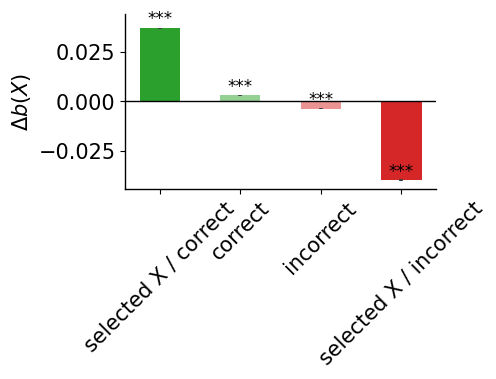

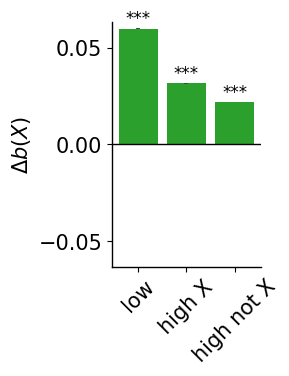

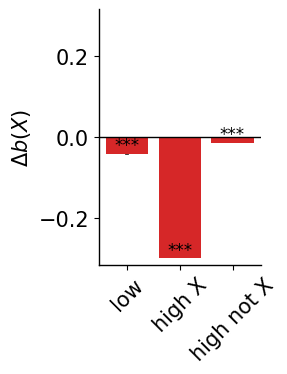

In [6]:
BEH_DATA_DIR = "/data/patrick_res/belief_update_changes/both_StimOnset"
# the belief_update_changes.py run to draw: "belief_changes", or "belief_changes_session_flips" for
# sign flips per session; the latter's figures get a _session_flips suffix
BEH_RUN = "belief_changes"
BEH_OUTPUT_DIR = "/data/patrick_res/figures/wcst_paper/change_in_beliefs_by_obs"
BEH_SUFFIX = BEH_RUN.removeprefix("belief_changes")
BEH_YLABEL = r"$\Delta b(X)$"
os.makedirs(BEH_OUTPUT_DIR, exist_ok=True)

def read_beh(name):
    return pd.read_pickle(os.path.join(BEH_DATA_DIR, f"{BEH_RUN}_{name}.pickle"))

beh_stats = read_beh("stats")
beh_cells = read_beh("cells")
beh_conditions = read_beh("conditions")

# db is stored as a pref-axis projection
plot_choice_reward(beh_conditions, "pref", BEH_YLABEL, f"{BEH_OUTPUT_DIR}/both_choice_reward_int{BEH_SUFFIX}")
for outcome in ["cor", "inc"]:
    plot_chose_reward_by_partitions(beh_cells, "pref", outcome, BEH_YLABEL,
                                    f"{BEH_OUTPUT_DIR}/both_chose_{OUTCOME_NAMES[outcome]}_by_partition{BEH_SUFFIX}")

beh_stats[["contrast", "plus", "minus", "mean_d", "n_units", "p"]].round(4)

## Combined figure

The paper figure, laid out as in its Inkscape file `change_in_beliefs_combined.svg`: the panels above
placed at that file's offsets, with its titles, panel letters and arrows. Each arrow sits under the
first or last bar of the panel above it. Conf's partitions are the `_split_high` ones. Written as svg
only.

In [ ]:
import re

PT_TO_MM = 25.4 / 72
# one column per model: title, title color, title and letter positions (mm), and its conditions,
# chose X / correct and chose X / incorrect panels with their top left corners (mm)
COMBINED_COLUMNS = [
    {"title": "Belief state model", "color": "#000000", "title_xy": (55.136642, 25.788605),
     "letter": "a", "letter_xy": (22.134056, 24.618654),
     "panels": [(f"{BEH_OUTPUT_DIR}/both_choice_reward_int{BEH_SUFFIX}.svg", 24.870833, 33.139064),
                (f"{BEH_OUTPUT_DIR}/both_chose_correct_by_partition{BEH_SUFFIX}.svg", 14.287501, 132.02701),
                (f"{BEH_OUTPUT_DIR}/both_chose_incorrect_by_partition{BEH_SUFFIX}.svg", 84.137502, 131.49793)]},
    {"title": "Confidence", "color": "#d62728", "title_xy": (216.62077, 24.586252),
     "letter": "b", "letter_xy": (163.42151, 24.618658),
     "panels": [(f"{OUTPUT_DIR}/conf_choice_reward_int.svg", 175.94791, 33.07292),
                (f"{OUTPUT_DIR}/conf_chose_correct_by_partition_split_high.svg", 163.51248, 131.23333),
                (f"{OUTPUT_DIR}/conf_chose_incorrect_by_partition_split_high.svg", 229.65832, 131.23333)]},
    {"title": "Preference", "color": "#1f77b4", "title_xy": (369.54269, 24.730274),
     "letter": "c", "letter_xy": (311.77014, 24.42436),
     "panels": [(f"{OUTPUT_DIR}/pref_choice_reward_int.svg", 323.05621, 33.601938),
                (f"{OUTPUT_DIR}/pref_chose_correct_by_partition.svg", 314.58953, 132.0269),
                (f"{OUTPUT_DIR}/pref_chose_incorrect_by_partition.svg", 383.38118, 131.76248)]},
]
ARROW_Y = (125.28017, 137.38345)

def inline_panel(path, prefix, x, y):
    """
    returns a matplotlib svg's contents as a group with its top left at (x, y) mm, its ids prefixed so
    panels don't collide, and the x (mm) of each of its x ticks
    """
    with open(path) as f:
        svg = f.read()
    body = re.search(r"<svg[^>]*>(.*)</svg>", svg, re.S).group(1)
    body = re.sub(r"<metadata>.*?</metadata>", "", body, flags=re.S)
    body = re.sub(r'id="([^"]+)"', rf'id="{prefix}\1"', body)
    body = body.replace("url(#", f"url(#{prefix}").replace('xlink:href="#', f'xlink:href="#{prefix}')
    ticks = re.findall(r'<g id="xtick_\d+">\s*<g id="line2d_\d+">.*?<use [^>]*\bx="([-\d.]+)"', svg, re.S)
    group = f'<g transform="matrix({PT_TO_MM},0,0,{PT_TO_MM},{x},{y})">{body}</g>'
    return group, [x + float(t) * PT_TO_MM for t in ticks]

def text(s, xy, color):
    return (f'<text x="{xy[0]}" y="{xy[1]}" style="font-weight:bold;font-size:8.46667px;'
            f'font-family:Sans;fill:{color}">{s}</text>')

def arrow(x):
    return (f'<path d="M {x},{ARROW_Y[0]} V {ARROW_Y[1]}" style="fill:none;stroke:#000000;'
            f'stroke-width:0.78098;marker-end:url(#arrowhead)"/>')

parts = []
for i, col in enumerate(COMBINED_COLUMNS):
    parts += [text(col["title"], col["title_xy"], col["color"]), text(col["letter"], col["letter_xy"], "#030303")]
    for j, (path, x, y) in enumerate(col["panels"]):
        group, tick_xs = inline_panel(path, f"c{i}p{j}_", x, y)
        parts.append(group)
        if j == 0:
            # under the chose X / correct and chose X / incorrect bars
            parts += [arrow(tick_xs[0]), arrow(tick_xs[-1])]

marker = ('<marker id="arrowhead" style="overflow:visible" refX="0" refY="0" orient="auto-start-reverse" '
          'markerWidth="1" markerHeight="1" viewBox="0 0 1 1" preserveAspectRatio="xMidYMid">'
          '<path transform="scale(0.5)" style="fill:#000000;fill-rule:evenodd;stroke:#000000;stroke-width:1pt" '
          'd="M 5.77,0 -2.88,5 V -5 Z"/></marker>')
combined = ('<?xml version="1.0" encoding="UTF-8" standalone="no"?>\n'
            '<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" '
            'width="620mm" height="600mm" viewBox="0 0 620 600" version="1.1">\n'
            f'<defs>{marker}</defs>\n' + "\n".join(parts) + "\n</svg>\n")
with open(f"{OUTPUT_DIR}/change_in_beliefs_combined{BEH_SUFFIX}.svg", "w") as f:
    f.write(combined)